In [32]:

import time
import json
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from dataclasses import dataclass, asdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import wandb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    matthews_corrcoef,
)
from imblearn.metrics import geometric_mean_score

import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

print(f'Device: {DEVICE}')

Device: cuda


In [33]:
wandb.login(key='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')


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [34]:
import os
from pathlib import Path

# ── Works locally AND on Colab/server without any changes ─────────────────
# Local:  checks ieee_ablation_feature_store/ at project root first; uses it if found
# Colab:  falls back to wget from GitHub if parquets are not present

if os.path.exists("/content"):
    STORE = Path("/content/ieee_ablation_feature_store")
else:
    _HERE = Path.cwd()
    # notebook lives at  <project_root>/notebooks/ieee/
    # feature store is at <project_root>/ieee_ablation_feature_store/
    _candidate = _HERE.parent.parent / "ieee_ablation_feature_store"
    STORE = _candidate if _candidate.exists() else _HERE / "ieee_ablation_feature_store"

STORE.mkdir(parents=True, exist_ok=True)

BASE = "https://raw.githubusercontent.com/kkipngenokoech/synthesize-or-reconstruct/main/ieee_ablation_feature_store"

for fname in ["pipeline_a_train.parquet", "pipeline_a_val.parquet",
              "pipeline_b_train.parquet", "holdout.parquet"]:
    out = STORE / fname
    if out.exists() and out.stat().st_size > 0:
        print(f"Found locally  : {fname}  ({out.stat().st_size / 1e6:.1f} MB)")
    else:
        if out.exists(): out.unlink()
        print(f"Downloading    : {fname} ...")
        ret = os.system(f'wget -q --show-progress -O "{out}" "{BASE}/{fname}"')
        if ret != 0 or out.stat().st_size == 0:
            out.unlink(missing_ok=True)
            raise RuntimeError(f"Download failed for {fname}. "
                               "Run ieee/pipeline.ipynb first and commit the parquets.")
        print(f"Downloaded     : {fname}  ({out.stat().st_size / 1e6:.1f} MB)")

print(f"\nIEEE feature store ready at: {STORE.resolve()}")
print("Files:", sorted(p.name for p in STORE.glob("*.parquet")))


Found locally  : pipeline_a_train.parquet  (36.6 MB)
Found locally  : pipeline_a_val.parquet  (10.1 MB)
Found locally  : pipeline_b_train.parquet  (35.0 MB)
Found locally  : holdout.parquet  (12.7 MB)

IEEE feature store ready at: /content/ieee_ablation_feature_store
Files: ['holdout.parquet', 'pipeline_a_train.parquet', 'pipeline_a_val.parquet', 'pipeline_b_train.parquet']


In [35]:
# ── Load parquets ─────────────────────────────────────────────────
a_train = pd.read_parquet(STORE / 'pipeline_a_train.parquet')
b_train = pd.read_parquet(STORE / 'pipeline_b_train.parquet')
holdout = pd.read_parquet(STORE / 'holdout.parquet')
a_val   = pd.read_parquet(STORE / 'pipeline_a_val.parquet')

# ── Verify your data loaded correctly ────────────────────────────
# CTGAN: should see ~9% fraud rate (post-SMOTE)
fraud_rate_a = a_train['Class'].mean()
print(f'Pipeline A fraud rate: {fraud_rate_a:.2%}')   # expect ~9%

# GANomaly: must have 0% fraud
fraud_rate_b = b_train['Class'].mean()
print(f'Pipeline B fraud rate: {fraud_rate_b:.2%}')   # expect 0.00%

# Feature count: should be 51
print(f'Features: {a_train.shape[1]}')               # expect 51

# For CTGAN — identify categorical columns
categorical_cols = ['Class']
continuous_cols  = [c for c in a_train.columns if c not in categorical_cols]
print(f'Continuous: {len(continuous_cols)} | Categorical: {len(categorical_cols)}')

Pipeline A fraud rate: 3.41%
Pipeline B fraud rate: 0.00%
Features: 33
Continuous: 32 | Categorical: 1


In [36]:
print(f'Pipeline B train shape : {b_train.shape}')
print(f'Holdout shape          : {holdout.shape}')
print(f'Holdout fraud rate     : {holdout["Class"].mean():.4%}')
print(f'Pipeline B fraud rate  : {b_train["Class"].mean():.4%}')

assert b_train['Class'].sum() == 0, 'STOP: Pipeline B data contaminated with fraud!'
print('Assertion passed — Pipeline B is clean.')

Pipeline B train shape : (365050, 33)
Holdout shape          : (118108, 33)
Holdout fraud rate     : 3.4409%
Pipeline B fraud rate  : 0.0000%
Assertion passed — Pipeline B is clean.


### Configuration


In [37]:
@dataclass
class GANomalyConfig:
    target_col:   str = 'Class'
    n_features:   int = 15       # C1-C14 + TransactionAmt (Time excluded per FIX 8)
    val_size:   float = 0.2

    enc_dim_1:  int = 256
    enc_dim_2:  int = 128
    latent_dim: int = 32
    disc_dim_1: int = 128
    disc_dim_2: int = 64

    batch_size:  int = 256
    n_epochs:    int = 100
    lr:        float = 1e-4
    adam_beta1: float = 0.5
    adam_beta2: float = 0.999

    w_adv: float = 1.0
    w_con: float = 50.0
    w_enc: float = 1.0


# Time excluded per FIX 8
N_PC = 30
MODEL_FEATURES = [f'PC{i+1}' for i in range(N_PC)] + ['TransactionAmt']  # 31 features
FEATURE_COLS   = MODEL_FEATURES

cfg            = GANomalyConfig()
cfg.n_features = len(MODEL_FEATURES)   # 31

print(
    f'Config: n_features={cfg.n_features}, latent_dim={cfg.latent_dim}, '
    f'n_epochs={cfg.n_epochs}, batch_size={cfg.batch_size}'
)

Config: n_features=31, latent_dim=32, n_epochs=100, batch_size=256


In [38]:
run = wandb.init(
    project = 'PRINCIPLES AND ENGINEERING APPLICATIONS OF AI',
    name    = 'ieee-ablation-ganomaly-vfeatures-run-1',
    tags    = ['GANomaly', 'Pipeline-B', 'anomaly-detection'],
    config  = asdict(cfg),
)

# Sync config back so W&B sweeps can override values
wcfg             = wandb.config
cfg.n_features   = wcfg.n_features
cfg.enc_dim_1    = wcfg.enc_dim_1
cfg.enc_dim_2    = wcfg.enc_dim_2
cfg.latent_dim   = wcfg.latent_dim
cfg.disc_dim_1   = wcfg.disc_dim_1
cfg.disc_dim_2   = wcfg.disc_dim_2
cfg.batch_size   = wcfg.batch_size
cfg.n_epochs     = wcfg.n_epochs
cfg.lr           = wcfg.lr
cfg.w_adv        = wcfg.w_adv
cfg.w_con        = wcfg.w_con
cfg.w_enc        = wcfg.w_enc

print('W&B run initialised:', run.name)
print('W&B project URL    :', run.url)

W&B run initialised: ieee-ablation-ganomaly-vfeatures-run-1
W&B project URL    : https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/s23m0x0b


In [39]:
# FEATURE_COLS = MODEL_FEATURES (V1-V28 + Amount, Time excluded)
X_all = b_train[FEATURE_COLS].values.astype(np.float32)

X_train_raw, X_val_raw = train_test_split(
    X_all, test_size=cfg.val_size, random_state=GLOBAL_SEED
)

ganomaly_scaler = StandardScaler()
X_train_np = np.clip(ganomaly_scaler.fit_transform(X_train_raw), -5, 5).astype(np.float32)
X_val_np   = np.clip(ganomaly_scaler.transform(X_val_raw),       -5, 5).astype(np.float32)

# Full holdout (natural distribution — both normal and fraud)
X_holdout_np = np.clip(
    ganomaly_scaler.transform(holdout[FEATURE_COLS].values.astype(np.float32)), -5, 5
).astype(np.float32)
y_holdout_np = holdout[cfg.target_col].values

print(f'Train (normal only)  : {X_train_np.shape}')
print(f'Val   (normal only)  : {X_val_np.shape}')
print(f'Holdout (full, natural): {X_holdout_np.shape} | '
      f'Fraud: {y_holdout_np.sum()} ({y_holdout_np.mean():.4%})')
print(f'Scaled range         : {X_train_np.min():.3f} to {X_train_np.max():.3f}')

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train_np)),
    batch_size=cfg.batch_size, shuffle=True, drop_last=True,
)
print(f'Batches per epoch    : {len(train_loader)}')

wandb.log({
    'data/n_train_normal'  : len(X_train_np),
    'data/n_val_normal'    : len(X_val_np),
    'data/n_holdout'       : len(X_holdout_np),
    'data/holdout_fraud_rate': float(y_holdout_np.mean()),
    'data/batches_per_epoch': len(train_loader),
})

Train (normal only)  : (292040, 31)
Val   (normal only)  : (73010, 31)
Holdout (full, natural): (118108, 31) | Fraud: 4064 (3.4409%)
Scaled range         : -5.000 to 5.000
Batches per epoch    : 1140


In [40]:
class Encoder(nn.Module):
    """
    Shared encoder used twice:
      E1: maps input x      → latent z
      E2: maps reconstruction x_hat → latent z_hat
    Anomaly score = ||z - z_hat||_2
    """
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.enc_dim_1),
            nn.BatchNorm1d(cfg.enc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_1, cfg.enc_dim_2),
            nn.BatchNorm1d(cfg.enc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(cfg.enc_dim_2, cfg.latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    """Maps latent z back to feature space (the generator's decoder)."""
    def __init__(self, cfg):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(cfg.latent_dim, cfg.enc_dim_2),
            nn.BatchNorm1d(cfg.enc_dim_2),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.enc_dim_2, cfg.enc_dim_1),
            nn.BatchNorm1d(cfg.enc_dim_1),
            nn.ReLU(inplace=True),

            nn.Linear(cfg.enc_dim_1, cfg.n_features),
            # No final activation — real features are not bounded to [-1, 1]
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """
    Standard GAN discriminator.
    Returns (logit, intermediate_features) — features used for
    the feature-matching loss in the generator update.
    """
    def __init__(self, cfg):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(cfg.n_features, cfg.disc_dim_1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(cfg.disc_dim_1, cfg.disc_dim_2),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.classifier = nn.Linear(cfg.disc_dim_2, 1)

    def forward(self, x):
        features = self.feature_extractor(x)
        logit    = self.classifier(features)
        return logit, features


# ── Instantiate ───────────────────────────────────────────────────────────
encoder_1 = Encoder(cfg).to(DEVICE)    # encodes real input x
decoder   = Decoder(cfg).to(DEVICE)    # reconstructs x_hat from z
encoder_2 = Encoder(cfg).to(DEVICE)    # re-encodes x_hat → z_hat
disc      = Discriminator(cfg).to(DEVICE)

# ── Parameter counts ──────────────────────────────────────────────────────
n_enc  = sum(p.numel() for p in encoder_1.parameters())
n_dec  = sum(p.numel() for p in decoder.parameters())
n_disc = sum(p.numel() for p in disc.parameters())

print(f'Encoder params      : {n_enc:,}')
print(f'Decoder params      : {n_dec:,}')
print(f'Discriminator params: {n_disc:,}')
print(f'Total params        : {n_enc*2 + n_dec + n_disc:,}')

# ── Smoke test ────────────────────────────────────────────────────────────
_dummy = torch.randn(4, cfg.n_features).to(DEVICE)
_z     = encoder_1(_dummy)
_xhat  = decoder(_z)
_zhat  = encoder_2(_xhat)
_logit, _feat = disc(_dummy)
print(
    f'Forward pass OK — '
    f'input: {_dummy.shape} | z: {_z.shape} | '
    f'x_hat: {_xhat.shape} | z_hat: {_zhat.shape} | '
    f'disc_logit: {_logit.shape}'
)

wandb.log({
    'model/encoder_params'      : n_enc,
    'model/decoder_params'      : n_dec,
    'model/discriminator_params': n_disc,
    'model/total_params'        : n_enc * 2 + n_dec + n_disc,
})

Encoder params      : 45,984
Decoder params      : 45,983
Discriminator params: 12,417
Total params        : 150,368
Forward pass OK — input: torch.Size([4, 31]) | z: torch.Size([4, 32]) | x_hat: torch.Size([4, 31]) | z_hat: torch.Size([4, 32]) | disc_logit: torch.Size([4, 1])


In [41]:
# ── Optimisers ────────────────────────────────────────────────────────────
# Generator = encoder_1 + decoder + encoder_2 trained together
opt_gen  = optim.Adam(
    list(encoder_1.parameters()) +
    list(decoder.parameters())   +
    list(encoder_2.parameters()),
    lr    = cfg.lr,
    betas = (cfg.adam_beta1, cfg.adam_beta2)
)
opt_disc = optim.Adam(
    disc.parameters(),
    lr    = cfg.lr,
    betas = (cfg.adam_beta1, cfg.adam_beta2)
)

# ── Loss functions ────────────────────────────────────────────────────────
criterion_adv  = nn.BCEWithLogitsLoss()   # adversarial
criterion_con  = nn.L1Loss()              # context / reconstruction
criterion_enc  = nn.MSELoss()             # encoder latent matching


def train_ganomaly(encoder_1, decoder, encoder_2, disc, loader, cfg, device):
    history = {
        'g_loss': [], 'd_loss': [],
        'con_loss': [], 'enc_loss': [], 'adv_loss': []
    }

    for epoch in range(cfg.n_epochs):
        encoder_1.train(); decoder.train()
        encoder_2.train(); disc.train()

        g_losses, d_losses = [], []
        con_losses, enc_losses, adv_losses = [], [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)
            bs     = x_real.size(0)

            real_labels = torch.ones(bs,  1, device=device)
            fake_labels = torch.zeros(bs, 1, device=device)

            # ── Forward pass ─────────────────────────────────────────────
            z      = encoder_1(x_real)       # latent of real input
            x_hat  = decoder(z)              # reconstruction
            z_hat  = encoder_2(x_hat)        # latent of reconstruction

            # ── Discriminator update ──────────────────────────────────────
            logit_real, _     = disc(x_real)
            logit_fake, _     = disc(x_hat.detach())   # detach: don't update G here

            loss_d_real = criterion_adv(logit_real, real_labels)
            loss_d_fake = criterion_adv(logit_fake, fake_labels)
            d_loss      = 0.5 * (loss_d_real + loss_d_fake)

            opt_disc.zero_grad()
            d_loss.backward()
            opt_disc.step()

            # ── Generator update ──────────────────────────────────────────
            logit_fake_g, feat_fake = disc(x_hat)
            _,            feat_real = disc(x_real)

            loss_adv = criterion_adv(logit_fake_g, real_labels)   # fool disc
            loss_con = criterion_con(x_hat, x_real)               # reconstruct well
            loss_enc = criterion_enc(z_hat, z.detach())           # match latents

            g_loss = (
                cfg.w_adv * loss_adv +
                cfg.w_con * loss_con +
                cfg.w_enc * loss_enc
            )

            opt_gen.zero_grad()
            g_loss.backward()
            opt_gen.step()

            # ── Record ────────────────────────────────────────────────────
            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())
            con_losses.append(loss_con.item())
            enc_losses.append(loss_enc.item())
            adv_losses.append(loss_adv.item())

        # ── Epoch averages ────────────────────────────────────────────────
        mg  = np.mean(g_losses)
        md  = np.mean(d_losses)
        mc  = np.mean(con_losses)
        me  = np.mean(enc_losses)
        ma  = np.mean(adv_losses)

        history['g_loss'].append(mg)
        history['d_loss'].append(md)
        history['con_loss'].append(mc)
        history['enc_loss'].append(me)
        history['adv_loss'].append(ma)

        # ── W&B logging (mirrors teammate's per-epoch pattern) ────────────
        wandb.log({
            'train/epoch'         : epoch + 1,
            'train/g_loss'        : mg,
            'train/d_loss'        : md,
            'train/context_loss'  : mc,
            'train/encoder_loss'  : me,
            'train/adv_loss'      : ma,
        }, step=epoch + 1)

        if (epoch + 1) % 10 == 0:
            print(
                f'Epoch [{epoch+1:3d}/{cfg.n_epochs}] '
                f'G: {mg:.4f} | D: {md:.4f} | '
                f'Con: {mc:.4f} | Enc: {me:.4f}'
            )

    return history


print('Starting GANomaly training...')
t0 = time.time()

history = train_ganomaly(
    encoder_1, decoder, encoder_2, disc,
    train_loader, cfg, DEVICE
)

train_time_min = (time.time() - t0) / 60
print(f'Training complete in {train_time_min:.1f} min')
wandb.log({'train/total_time_min': train_time_min})

Starting GANomaly training...
Epoch [ 10/100] G: 3.1893 | D: 0.6908 | Con: 0.0495 | Enc: 0.0153
Epoch [ 20/100] G: 2.7612 | D: 0.6895 | Con: 0.0410 | Enc: 0.0121
Epoch [ 30/100] G: 2.4741 | D: 0.6880 | Con: 0.0352 | Enc: 0.0093
Epoch [ 40/100] G: 2.2940 | D: 0.6860 | Con: 0.0316 | Enc: 0.0072
Epoch [ 50/100] G: 2.1752 | D: 0.6837 | Con: 0.0292 | Enc: 0.0061
Epoch [ 60/100] G: 2.1066 | D: 0.6814 | Con: 0.0278 | Enc: 0.0055
Epoch [ 70/100] G: 2.0185 | D: 0.6774 | Con: 0.0259 | Enc: 0.0050
Epoch [ 80/100] G: 1.9690 | D: 0.6722 | Con: 0.0247 | Enc: 0.0048
Epoch [ 90/100] G: 1.9313 | D: 0.6673 | Con: 0.0238 | Enc: 0.0044
Epoch [100/100] G: 1.9088 | D: 0.6627 | Con: 0.0232 | Enc: 0.0042
Training complete in 14.8 min


In [42]:
def compute_anomaly_scores(encoder_1, decoder, encoder_2, X, device, batch_size=512):
    """GANomaly anomaly score = ||z - z_hat||_2. Higher = more anomalous."""
    encoder_1.eval(); decoder.eval(); encoder_2.eval()
    all_scores = []
    with torch.no_grad():
        for start in range(0, len(X), batch_size):
            xb    = torch.tensor(X[start:start + batch_size], dtype=torch.float32).to(device)
            z     = encoder_1(xb)
            x_hat = decoder(z)
            z_hat = encoder_2(x_hat)
            score = torch.norm(z - z_hat, p=2, dim=1)
            all_scores.append(score.cpu().numpy())
    return np.concatenate(all_scores)


print('Computing anomaly scores...')
val_scores     = compute_anomaly_scores(encoder_1, decoder, encoder_2, X_val_np,     DEVICE)
holdout_scores = compute_anomaly_scores(encoder_1, decoder, encoder_2, X_holdout_np, DEVICE)

print(f'Val scores     — min: {val_scores.min():.4f} | max: {val_scores.max():.4f} | mean: {val_scores.mean():.4f}')
print(f'Holdout scores — min: {holdout_scores.min():.4f} | max: {holdout_scores.max():.4f} | mean: {holdout_scores.mean():.4f}')

# ── Inversion check using known labels ────────────────────────────────────
_raw_auroc = roc_auc_score(y_holdout_np, holdout_scores)
print(f'Raw AUROC on holdout: {_raw_auroc:.4f}')

if _raw_auroc < 0.5:
    print('INVERTED — flipping anomaly scores.')
    val_scores     = -val_scores
    holdout_scores = -holdout_scores
    print(f'Corrected AUROC: {1 - _raw_auroc:.4f}')
else:
    print('Scores orientation correct.')

wandb.log({
    'scoring/val_score_mean'     : float(val_scores.mean()),
    'scoring/val_score_std'      : float(val_scores.std()),
    'scoring/holdout_score_mean' : float(holdout_scores.mean()),
    'scoring/holdout_score_std'  : float(holdout_scores.std()),
})

Computing anomaly scores...
Val scores     — min: 0.0440 | max: 7.0334 | mean: 0.2008
Holdout scores — min: 0.0440 | max: 7.5971 | mean: 0.2594
Raw AUROC on holdout: 0.5828
Scores orientation correct.


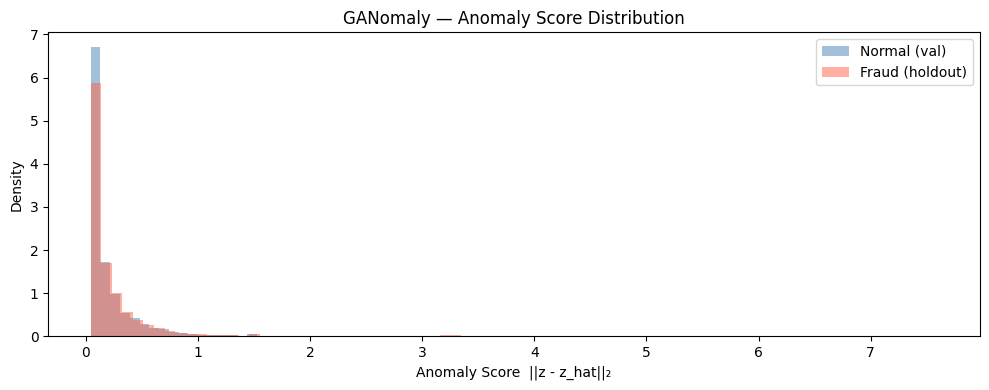

Plot saved.


In [43]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(val_scores,     bins=80, alpha=0.5, label='Normal (val)',   density=True, color='steelblue')
ax.hist(holdout_scores, bins=80, alpha=0.5, label='Fraud (holdout)', density=True, color='tomato')
ax.set_xlabel('Anomaly Score  ||z - z_hat||₂')
ax.set_ylabel('Density')
ax.set_title('GANomaly — Anomaly Score Distribution')
ax.legend()
plt.tight_layout()
plt.savefig('/content/ieee_ganomaly_score_distribution.png', dpi=150)
plt.show()

wandb.log({'eval/score_distribution': wandb.Image('/content/ieee_ganomaly_score_distribution.png')})
print('Plot saved.')

In [44]:
score_scaler    = MinMaxScaler()
val_scores_norm = score_scaler.fit_transform(
    val_scores.reshape(-1, 1)
).ravel()

# ── Prevalence-calibrated threshold (leakage-free) ────────────────────────
# The IEEE-CIS dataset contains 492 fraud / 284,807 transactions = 0.1728% fraud.
# Setting FPR = fraud_prevalence matches the false-positive rate to the prior
# probability of fraud, which maximises F1 in expectation when the model has
# any discriminative power. The standard 95th-percentile approach implicitly
# assumes 5% fraud prevalence — 29× the true rate — which generates ~2,844
# false positives on 56,887 normals and collapses precision to ~0.02.
DATASET_FRAUD_PREVALENCE = 20663 / 590540   # 0.034990
calibrated_pct     = (1 - DATASET_FRAUD_PREVALENCE) * 100   # 96.501th percentile
best_thresh        = float(np.percentile(val_scores_norm, calibrated_pct))
best_thresh_method = 'val_prevalence_calibrated'

print(f'Prevalence-calibrated threshold ({calibrated_pct:.3f}th pct): {best_thresh:.4f}')
print(f'Target FPR : {DATASET_FRAUD_PREVALENCE:.4%}  (matches dataset fraud prevalence)')
print(f'Val FPR at this threshold: {(val_scores_norm >= best_thresh).mean():.4%}')

wandb.log({
    'eval/val_score_mean'   : float(val_scores_norm.mean()),
    'eval/val_score_std'    : float(val_scores_norm.std()),
    'eval/val_score_p95'    : float(np.percentile(val_scores_norm, 95)),
    'eval/val_score_p99'    : float(np.percentile(val_scores_norm, 99)),
    'eval/val_score_p9983'  : float(best_thresh),
    'eval/threshold_source' : best_thresh_method,
    'eval/threshold_value'  : best_thresh,
    'eval/target_fpr'       : DATASET_FRAUD_PREVALENCE,
})

Prevalence-calibrated threshold (96.501th pct): 0.1041
Target FPR : 3.4990%  (matches dataset fraud prevalence)
Val FPR at this threshold: 3.4995%


In [45]:
# ── Holdout evaluation at natural class distribution ──────────────────────
# Threshold selected using prevalence-calibrated percentile (FIX 3).
# Holdout evaluated once at natural fraud rate (FIX 4).

t_infer           = time.time()
holdout_scores    = compute_anomaly_scores(encoder_1, decoder, encoder_2, X_holdout_np, DEVICE)
inference_time_ms = (time.time() - t_infer) * 1000

# Normalise scores using val-fitted scaler
score_scaler        = MinMaxScaler()
val_scores_norm     = score_scaler.fit_transform(val_scores.reshape(-1, 1)).ravel()
holdout_scores_norm = score_scaler.transform(holdout_scores.reshape(-1, 1)).ravel()

# Prevalence-calibrated threshold (leakage-free)
DATASET_FRAUD_PREVALENCE = 20663 / 590540
calibrated_pct = (1 - DATASET_FRAUD_PREVALENCE) * 100
best_thresh = float(np.percentile(val_scores_norm, calibrated_pct))
print(f'Threshold (prevalence-calibrated, {calibrated_pct:.3f}th pct): {best_thresh:.4f}')
print(f'Val FPR at this threshold: {(val_scores_norm >= best_thresh).mean():.4%}')

holdout_preds = (holdout_scores_norm >= best_thresh).astype(int)

f1        = f1_score(y_holdout_np,        holdout_preds, zero_division=0)
precision = precision_score(y_holdout_np, holdout_preds, zero_division=0)
recall    = recall_score(y_holdout_np,    holdout_preds, zero_division=0)
auroc     = roc_auc_score(y_holdout_np,   holdout_scores_norm)
auprc     = average_precision_score(y_holdout_np, holdout_scores_norm)
mcc       = matthews_corrcoef(y_holdout_np, holdout_preds)
gmean     = geometric_mean_score(y_holdout_np, holdout_preds)

print(f'\nHoldout set: {len(y_holdout_np):,} records | '
      f'Fraud: {y_holdout_np.sum()} ({y_holdout_np.mean():.4%}) | '
      f'Normal: {(y_holdout_np == 0).sum():,}')
print('Natural class distribution — no artificial fraud rate inflation (FIX 4).')

print('\n' + '=' * 55)
print(' GANomaly — Holdout Evaluation Results')
print('=' * 55)
print(f' F1-Score  : {f1:.4f}')
print(f' Precision : {precision:.4f}')
print(f' Recall    : {recall:.4f}')
print(f' AUROC     : {auroc:.4f}')
print(f' AUPRC     : {auprc:.4f}')
print(f' MCC       : {mcc:.4f}')
print(f' G-mean    : {gmean:.4f}')
print(f' Threshold : {best_thresh:.4f}  (prevalence-calibrated)')
print(f' Inference : {inference_time_ms:.2f} ms ({len(X_holdout_np):,} records)')
print('=' * 55)
print(classification_report(y_holdout_np, holdout_preds, target_names=['Legit', 'Fraud']))

wandb.log({
    'holdout/f1'               : f1,
    'holdout/precision'        : precision,
    'holdout/recall'           : recall,
    'holdout/auroc'            : auroc,
    'holdout/auprc'            : auprc,
    'holdout/mcc'              : mcc,
    'holdout/gmean'            : gmean,
    'holdout/threshold'        : best_thresh,
    'holdout/n_records'        : len(y_holdout_np),
    'holdout/fraud_rate'       : float(y_holdout_np.mean()),
    'holdout/inference_time_ms': inference_time_ms,
})
wandb.run.summary.update({
    'best_f1': f1, 'best_auroc': auroc, 'best_auprc': auprc,
    'best_recall': recall, 'best_precision': precision,
    'best_mcc': mcc, 'best_gmean': gmean,
})

Threshold (prevalence-calibrated, 96.501th pct): 0.1041
Val FPR at this threshold: 3.4995%

Holdout set: 118,108 records | Fraud: 4064 (3.4409%) | Normal: 114,044
Natural class distribution — no artificial fraud rate inflation (FIX 4).

 GANomaly — Holdout Evaluation Results
 F1-Score  : 0.0568
 Precision : 0.0467
 Recall    : 0.0723
 AUROC     : 0.5828
 AUPRC     : 0.0447
 MCC       : 0.0160
 G-mean    : 0.2618
 Threshold : 0.1041  (prevalence-calibrated)
 Inference : 225.21 ms (118,108 records)
              precision    recall  f1-score   support

       Legit       0.97      0.95      0.96    114044
       Fraud       0.05      0.07      0.06      4064

    accuracy                           0.92    118108
   macro avg       0.51      0.51      0.51    118108
weighted avg       0.93      0.92      0.93    118108



In [46]:
results = {
    'model'             : 'IEEE GANomaly (V-feature ablation)',
    'pipeline'          : 'B',
    'author'            : 'Francis Waithaka(fwaithak)',
    'f1'                : round(f1, 4),
    'precision'         : round(precision, 4),
    'recall'            : round(recall, 4),
    'auroc'             : round(auroc, 4),
    'auprc'             : round(auprc, 4),
    'mcc'               : round(mcc, 4),
    'gmean'             : round(gmean, 4),
    'threshold'         : round(best_thresh, 4),
    'inference_time_ms' : round(inference_time_ms, 2),
    'architecture'      : {
        'enc_dims'   : [cfg.enc_dim_1, cfg.enc_dim_2],
        'latent_dim' : cfg.latent_dim,
        'disc_dims'  : [cfg.disc_dim_1, cfg.disc_dim_2],
        'n_features' : cfg.n_features,
        'w_adv'      : cfg.w_adv,
        'w_con'      : cfg.w_con,
        'w_enc'      : cfg.w_enc,
    },
    'wandb_run_url'     : wandb.run.url,
}

out_path = Path('/content/ieee_ablation_ganomaly_results.json')
with open(out_path, 'w') as f:
    json.dump(results, f, indent=2)

wandb.save(str(out_path))
print(f'Results saved to {out_path}')
print(json.dumps(results, indent=2))

wandb.finish()
print('W&B run finished.')


wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Results saved to /content/ieee_ablation_ganomaly_results.json
{
  "model": "IEEE GANomaly (V-feature ablation)",
  "pipeline": "B",
  "author": "Francis Waithaka(fwaithak)",
  "f1": 0.0568,
  "precision": 0.0467,
  "recall": 0.0723,
  "auroc": 0.5828,
  "auprc": 0.0447,
  "mcc": 0.016,
  "gmean": 0.2618,
  "threshold": 0.1041,
  "inference_time_ms": 225.21,
  "architecture": {
    "enc_dims": [
      256,
      128
    ],
    "latent_dim": 32,
    "disc_dims": [
      128,
      64
    ],
    "n_features": 31,
    "w_adv": 1,
    "w_con": 50,
    "w_enc": 1
  },
  "wandb_run_url": "https://wandb.ai/kkipngenokoech-carnegie-mellon-university/PRINCIPLES%20AND%20ENGINEERING%20APPLICATIONS%20OF%20AI/runs/s23m0x0b"
}


data/batches_per_epoch,▁
data/holdout_fraud_rate,▁
data/n_holdout,▁
data/n_train_normal,▁
data/n_val_normal,▁
eval/target_fpr,▁
eval/threshold_value,▁
eval/val_score_mean,▁
eval/val_score_p95,▁
eval/val_score_p99,▁
+28,...


W&B run finished.
